In [30]:
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer
from sklearn.neighbors import LocalOutlierFactor

In [3]:
df1_train  = pd.read_csv('../data/phase_1/Training_dataset_1.csv', na_values=['-999.25']) 
df2_train  = pd.read_csv('../data/phase_1/Training_dataset_2.csv', na_values=['-999.25'])  
df3_train  = pd.read_csv('../data/phase_1/Training_dataset_3.csv', na_values=['-999.25'])  

df1_test   = pd.read_csv('../data/phase_1/Test_dataset_1.csv')
df2_test   = pd.read_csv('../data/phase_1/Test_dataset_2.csv')
df3_test   = pd.read_csv('../data/phase_1/Test_dataset_3.csv')

In [14]:
import missingno as msno
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
import matplotlib.pyplot as plt

def debug_missing_data(df, threshold=20):
    """
    Debug missing data analysis for numerical columns with detailed shape information at each step.
    
    Parameters:
    df (pandas.DataFrame): Input DataFrame
    threshold (float): Max percentage of missing values allowed
    
    Returns:
    pandas.DataFrame: Imputed DataFrame with only numerical columns, or None if process fails
    """
    # Step 1: Select only numeric columns
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
    df_numeric = df[numeric_cols].copy()
    
    print("Step 1: Initial DataFrame Info")
    print(f"Original DataFrame shape: {df.shape}")
    print(f"Numeric-only DataFrame shape: {df_numeric.shape}")
    print("\nNumeric columns selected:")
    print(df_numeric.columns.tolist())
    
    # Step 2: Calculate missing percentages for numeric columns
    missing_percentage = df_numeric.isnull().sum() / len(df_numeric) * 100
    missing_df = pd.DataFrame({
        'Column': missing_percentage.index,
        'Missing Percentage': missing_percentage.values
    }).sort_values('Missing Percentage', ascending=False)
    
    print("\nStep 2: Missing Value Analysis (Numeric Columns Only)")
    print(missing_df)
    
    # Step 3: Filter columns with missing data below threshold
    cols_with_missing = missing_df[missing_df['Missing Percentage'] < threshold]['Column'].tolist()
    print(f"\nStep 3: Numeric columns with <{threshold}% missing values:")
    print(cols_with_missing)
    
    
    # Step 3.1: Filter columns with missing data below threshold
    cols_with_missing1 = missing_df[missing_df['Missing Percentage'] > threshold]['Column'].tolist()
    print(f"\nStep 3.1: Numeric columns with >{threshold}% missing values:")
    print(cols_with_missing1)
    
    if len(cols_with_missing) > 0:
        # Step 4: Prepare data for imputation
        df_to_impute = df_numeric[cols_with_missing].copy()
        print("\nStep 4: Pre-imputation Data Check")
        print(f"Shape of data to be imputed: {df_to_impute.shape}")
        print("\nColumns to be imputed:")
        print(df_to_impute.columns.tolist())
        
        # Step 5: Check data types
        print("\nStep 5: Data Types Check")
        print(df_to_impute.dtypes)
        
        # Step 6: Attempt imputation
        print("\nStep 6: Attempting Imputation")
        try:
            imputer = KNNImputer()
            print("Starting imputer...")
            df_filled_array = imputer.fit_transform(df_to_impute)
            print("Imputation completed")
            print(f"Shape of training data: {df_to_impute.shape}")
            print(f"Shape of imputed array: {df_filled_array.shape}")
            
            # Create DataFrame from imputed values
            df_filled = pd.DataFrame(df_filled_array, columns=df_to_impute.columns)
            print(f"Shape of final DataFrame: {df_filled.shape}")
            
            # Verify column alignment
            print("\nColumn alignment check:")
            print("Input columns:", df_to_impute.columns.tolist())
            print("Output columns:", df_filled.columns.tolist())
            
            return df_filled
            
        except ValueError as e:
            print(f"\nError during imputation: {e}")
            return None
    else:
        print("No numeric columns with missing data found above the threshold.")
        return None

# Usage

debug_missing_data(df3_train).to_csv('../data/phase_1/training_dataset_3_imputed.csv', index=False)

Step 1: Initial DataFrame Info
Original DataFrame shape: (6995, 89)
Numeric-only DataFrame shape: (6995, 88)

Numeric columns selected:
['AD Delta-P SP (psi)', 'AD ROP SP (ft/hr)', 'AD Torque SP (kft·lbf)', 'AD WOB SP (klb)', 'Accum Trip In (bbl)', 'Accum Trip Out (bbl)', 'Annular Velocity (ft/min)', 'BHA Length (ft)', 'Bit MSE (psi)', 'Bit Position (ft)', 'Bit RPM (RPM)', 'Bit Size (in)', 'Bit Time (hr)', 'Bit Weight (klb)', 'Block Height (ft)', 'Bttm Pipe Temp (°F)', 'Casing Pressure (psi)', 'Circulating Hrs (hr)', 'Co. Man G/L (bbl)', 'Cont Az (deg)', 'Cont Inc (deg)', 'Depth of Cut (ft)', 'Depth(ft)', 'Diff Press (psi)', 'East West Horizontal (ft)', 'Flow Deviation (%)', 'Flow In Rate (galUS/min)', 'Flow Out Percent (%)', 'G/L Rate - 1 Min (bbl/min)', 'G/L Rate - 5 Min (bbl/min)', 'Gain Loss (bbl)', 'Gain Loss - Spare (bbl)', 'Gamma Depth (ft)', 'Gamma Ray (offset) (API)', 'Hole Depth (ft)', 'Hook Load (klb)', 'Lst Jnt Time (s)', 'ML Mud Temp IN (°F)', 'ML Mud Temp OUT (°F)', 'MSE 

In [4]:
df1_clean = pd.read_csv('../data/phase_1/training_dataset_1_imputed.csv')
df2_clean = pd.read_csv('../data/phase_1/training_dataset_2_imputed.csv')
df3_clean = pd.read_csv('../data/phase_1/training_dataset_3_imputed.csv')

In [17]:
# Get the column names of df1_clean and df2_clean
df1_columns = set(df1_clean.columns)
df2_columns = set(df2_clean.columns)


# get the columns that in df2 but not in df1
df2_not_in_df1 = df2_columns - df1_columns

In [18]:
df2_clean.drop(columns=list(df2_not_in_df1), inplace=True)

In [19]:
df3_clean.drop(columns=list(df2_not_in_df1), inplace=True)

In [34]:
df2_clean.to_csv('../data/phase_1/training_dataset_2_imputed.csv', index=False)

In [20]:
df3_clean.to_csv('../data/phase_1/training_dataset_3_imputed.csv', index=False)

In [62]:
# Find the 99th percentile (top 1%)
clf = LocalOutlierFactor(n_neighbors=20, contamination=0.1)
clf.fit_predict(df3_clean)
scores = clf.negative_outlier_factor_
scores = (scores - np.min(scores)) / (np.max(scores) - np.min(scores))
threshold = np.percentile(scores, 99)
filtered_scores = scores[scores < threshold]
print(f"Original length: {len(scores)}")
print(f"New length: {len(filtered_scores)}")
print(f"Removed {len(scores) - len(filtered_scores)} points")
print(f"Threshold value: {threshold:.4f}")

# Get indices of points to keep
keep_indices = np.where(scores < threshold)[0]

# Or get indices of points to remove
remove_indices = np.where(scores >= threshold)[0]

# Apply to your original data
df3_clean = df3_clean[scores < threshold]

Original length: 6925
New length: 6855
Removed 70 points
Threshold value: 0.9995


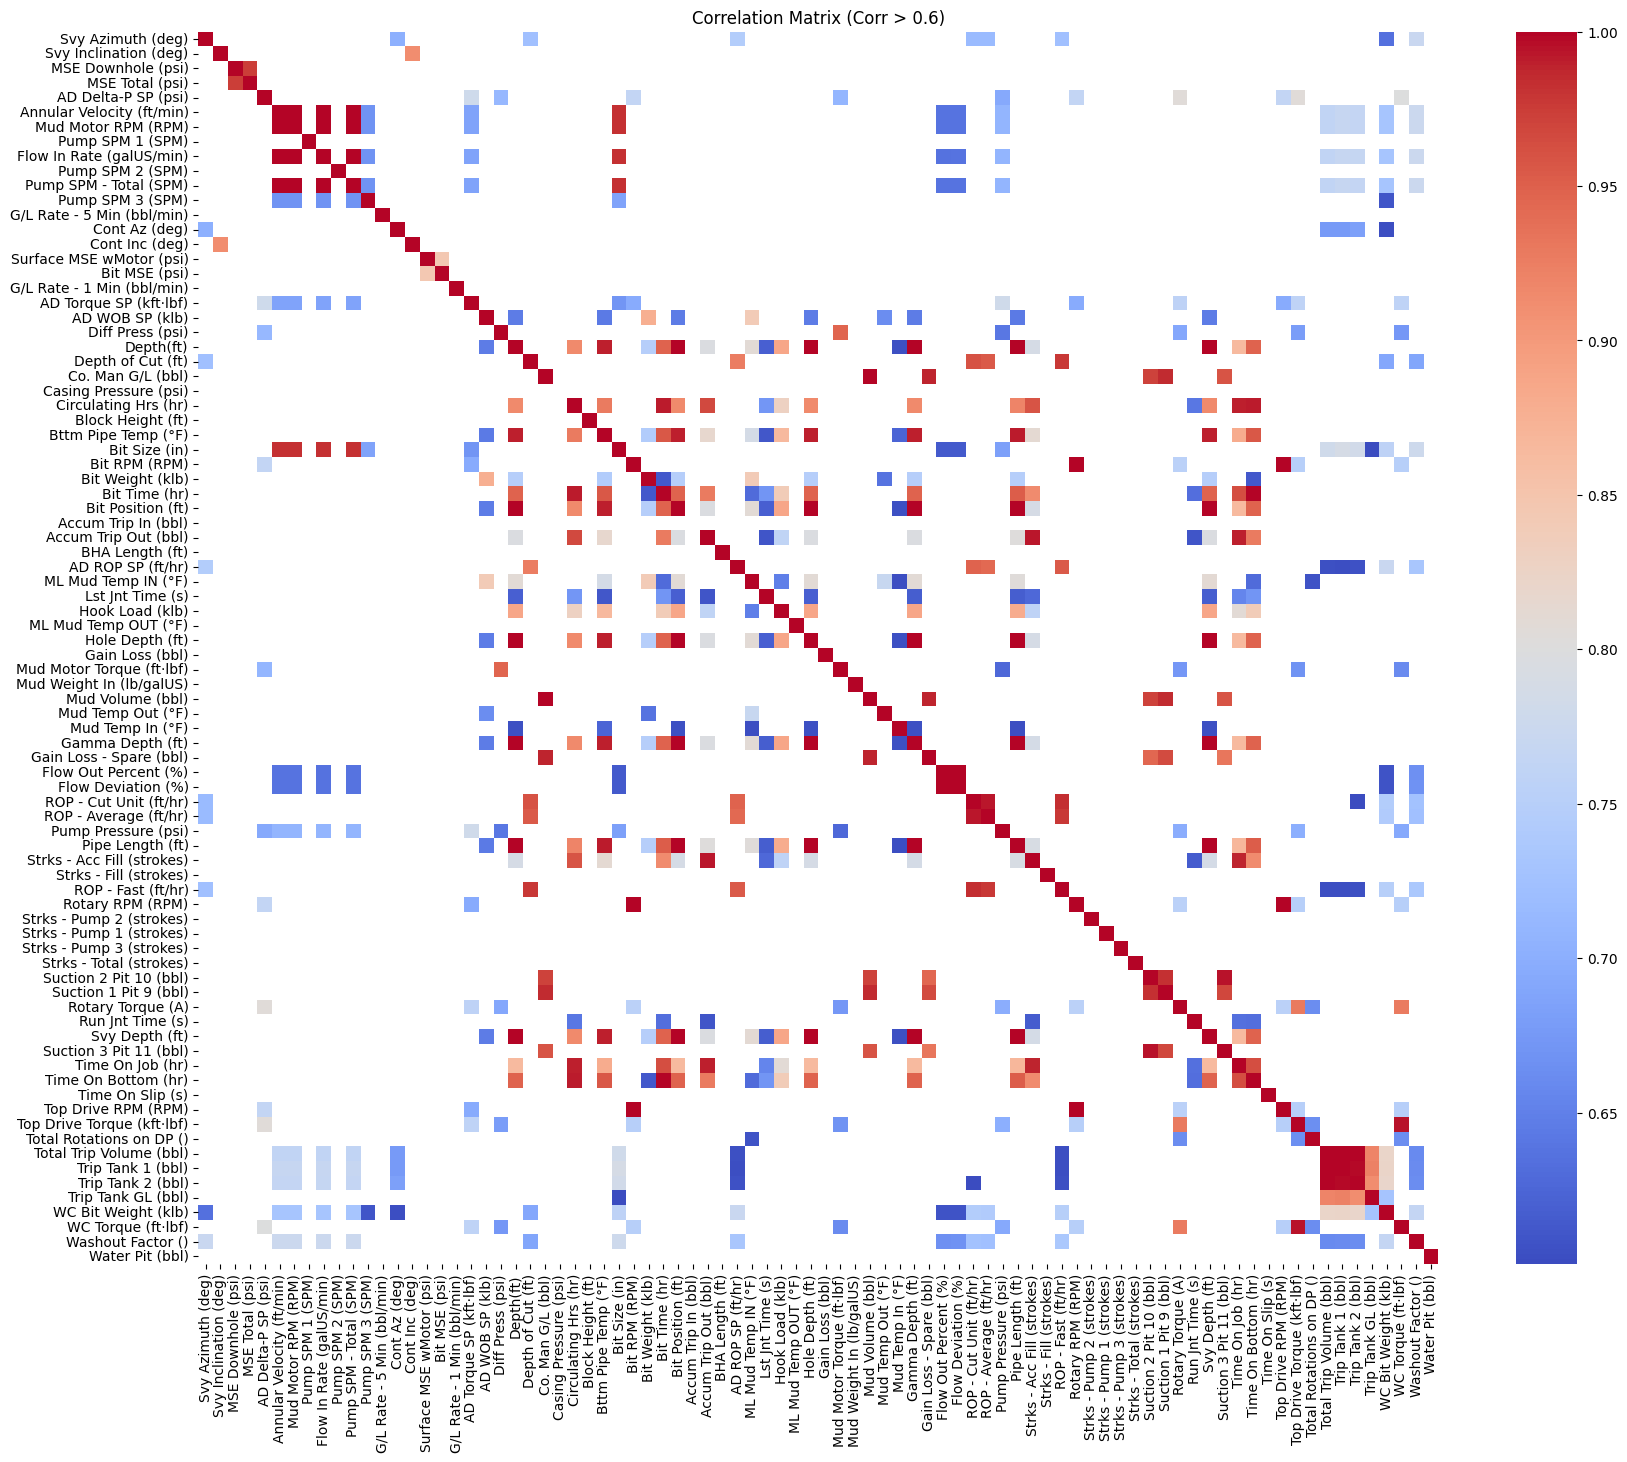

In [21]:
import seaborn as sns

# Create correlation matrix
corr = df3_clean.corr()
# Filter correlation matrix
high_corr = corr[corr>0.6]

# Plot correlation matrix heatmap



plt.figure(figsize=(20, 16))
sns.heatmap(high_corr, annot=False, cmap='coolwarm')
plt.title('Correlation Matrix (Corr > 0.6)')
plt.show()

In [22]:
filtered_corr = corr.loc['Bttm Pipe Temp (°F)', :][corr.loc['Bttm Pipe Temp (°F)', :] > 0].sort_values(ascending=False)

In [23]:
positive_corrs_cols = filtered_corr.index.tolist()

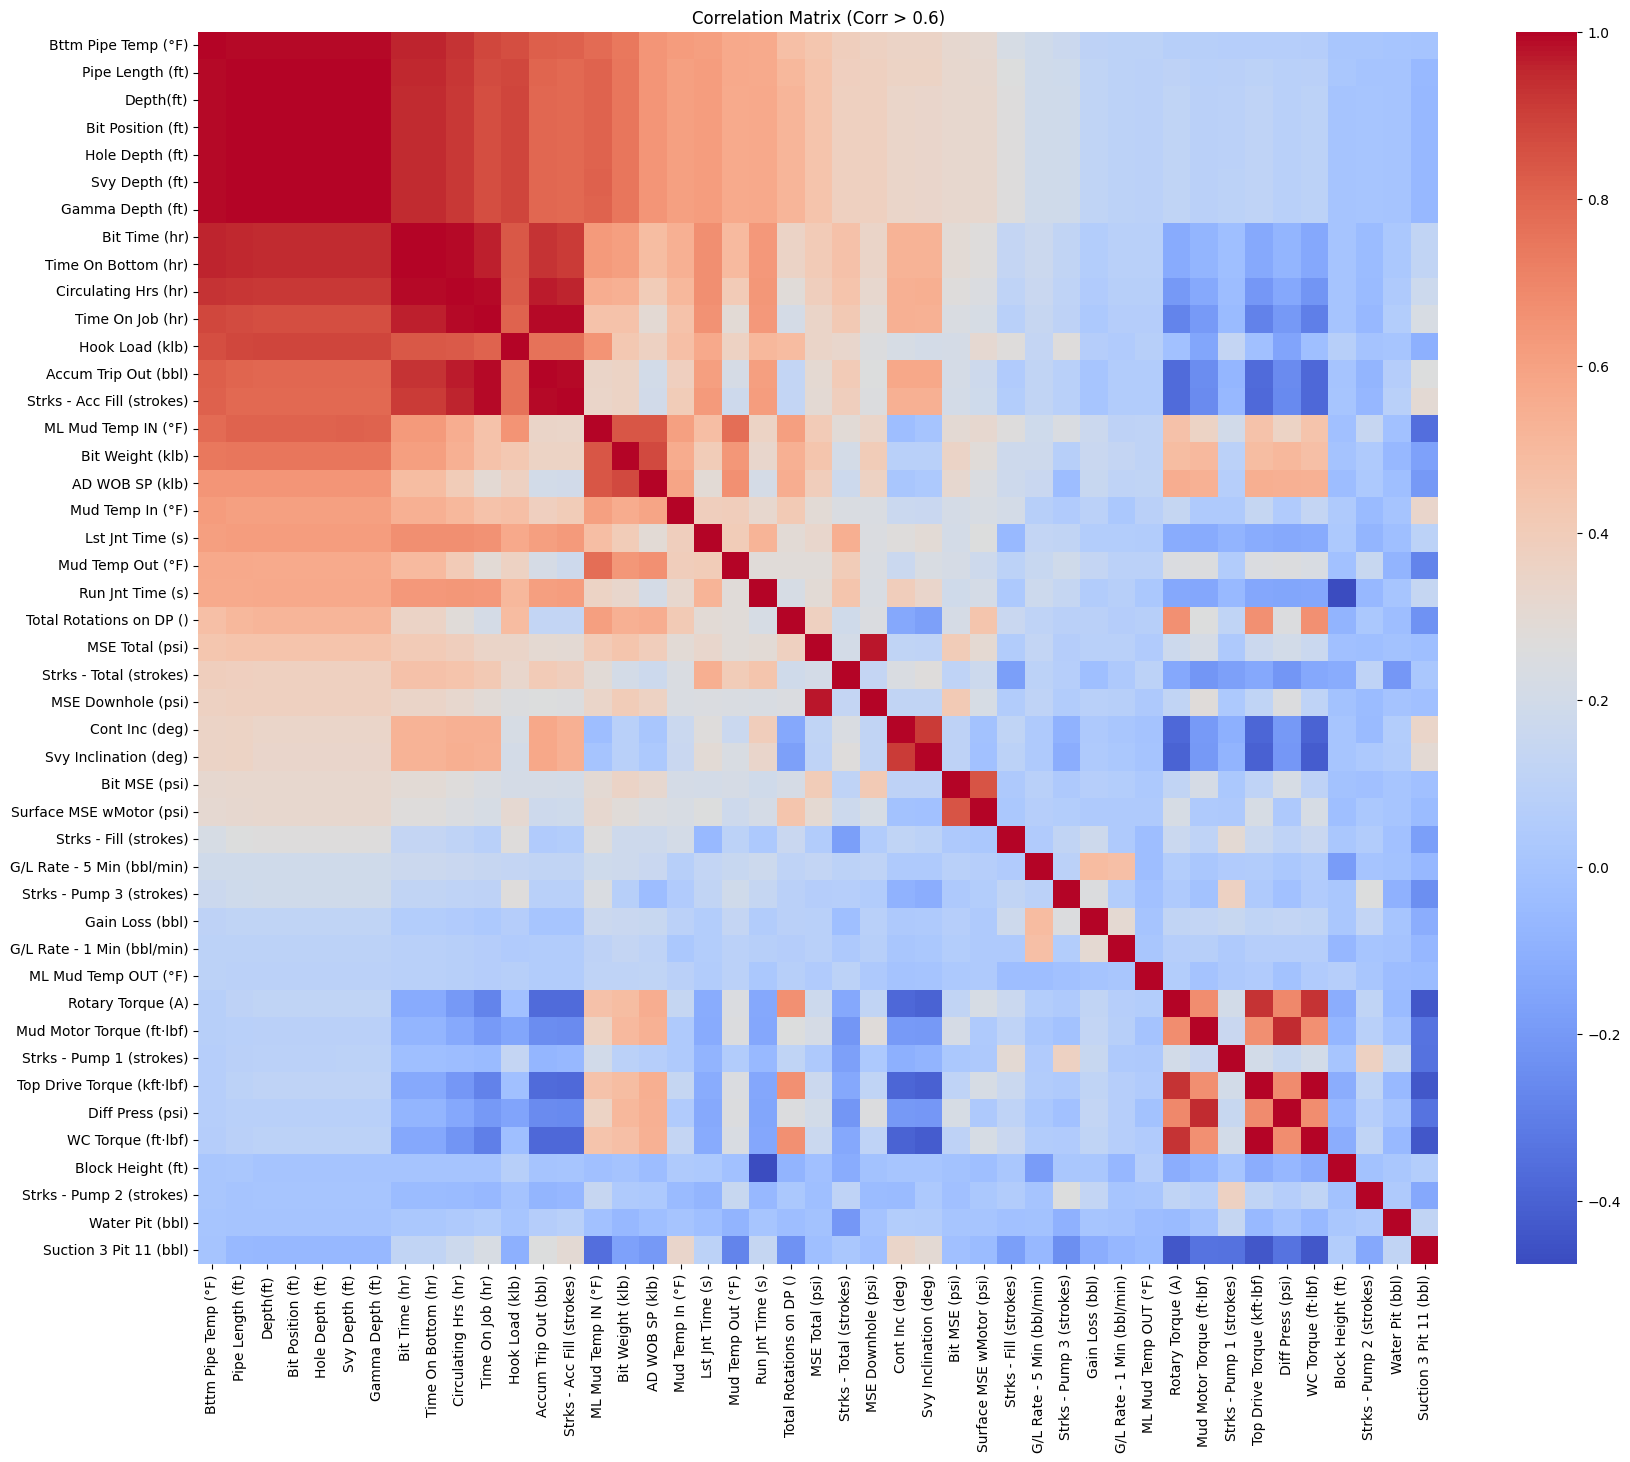

In [26]:
df3_clean[positive_corrs_cols].corr()

#plot the corr matrix
plt.figure(figsize=(20, 16))
sns.heatmap(df3_clean[positive_corrs_cols].corr(), annot=False, cmap='coolwarm')
plt.title('Correlation Matrix (Corr > 0.6)')
plt.show()

<BarContainer object of 45 artists>

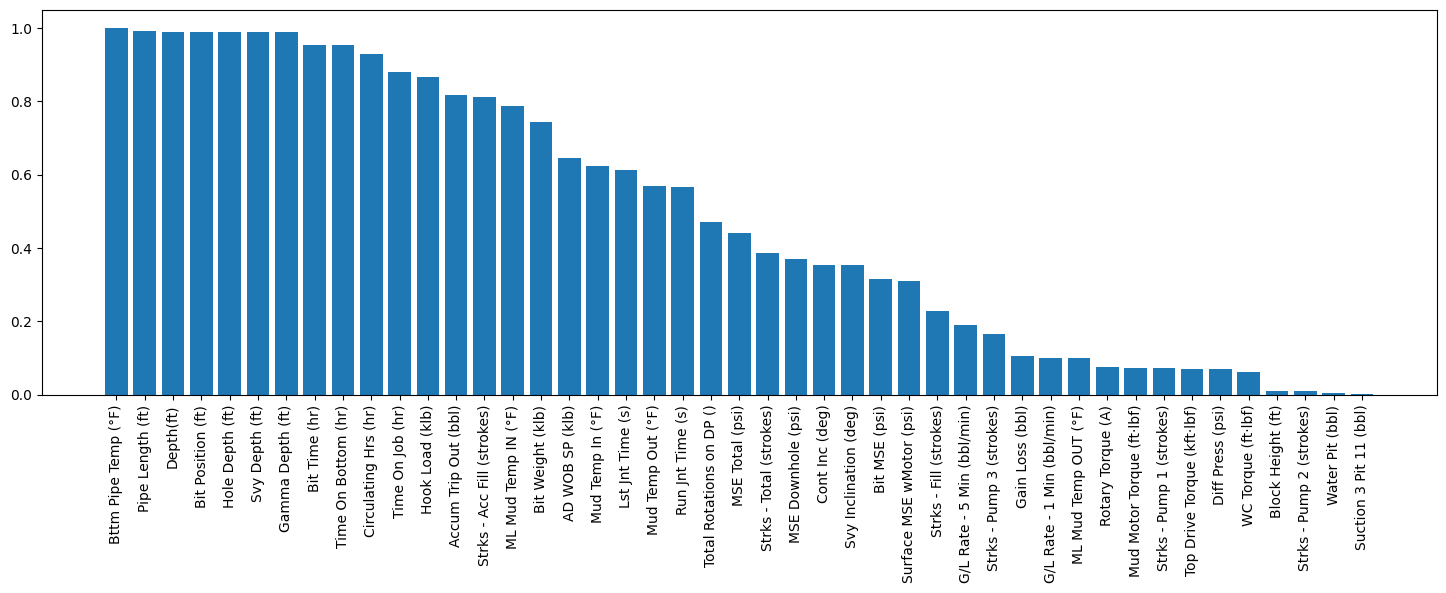

In [24]:
# rotate labels
plt.figure(figsize=(18, 5))
plt.xticks(rotation=90)
plt.bar(filtered_corr.index, filtered_corr.values)

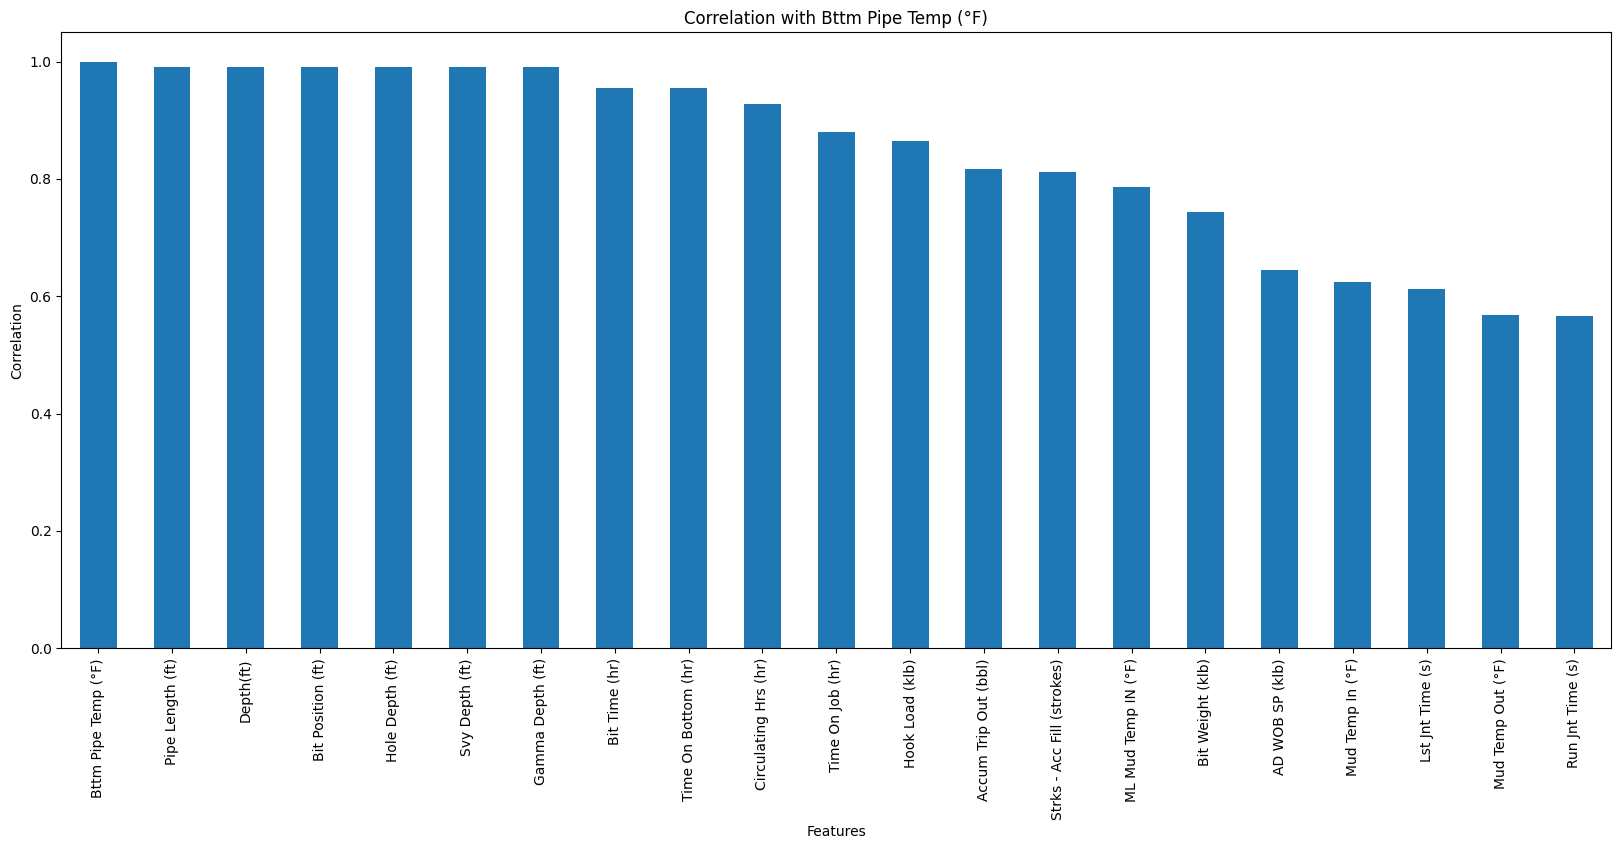

In [8]:
# draw a barchart for filtered_corr
plt.figure(figsize=(20, 8))
filtered_corr.plot(kind='bar')
plt.title('Correlation with Bttm Pipe Temp (°F)')
plt.xlabel('Features')
plt.ylabel('Correlation')
plt.show()


In [112]:
# display only more than 0.5 correlation
filtered_corr = filtered_corr[filtered_corr>0.9]

In [9]:
filtered_corr

Bttm Pipe Temp (°F)           1.000000
Pipe Length (ft)              0.991321
Depth(ft)                     0.990225
Bit Position (ft)             0.990225
Hole Depth (ft)               0.990225
Svy Depth (ft)                0.990157
Gamma Depth (ft)              0.990150
Bit Time (hr)                 0.954941
Time On Bottom (hr)           0.954941
Circulating Hrs (hr)          0.928037
Time On Job (hr)              0.880599
Hook Load (klb)               0.865380
Accum Trip Out (bbl)          0.816417
Strks - Acc Fill (strokes)    0.811670
ML Mud Temp IN (°F)           0.786532
Bit Weight (klb)              0.743150
AD WOB SP (klb)               0.644374
Mud Temp In (°F)              0.623595
Lst Jnt Time (s)              0.611531
Mud Temp Out (°F)             0.568082
Run Jnt Time (s)              0.566204
Name: Bttm Pipe Temp (°F), dtype: float64

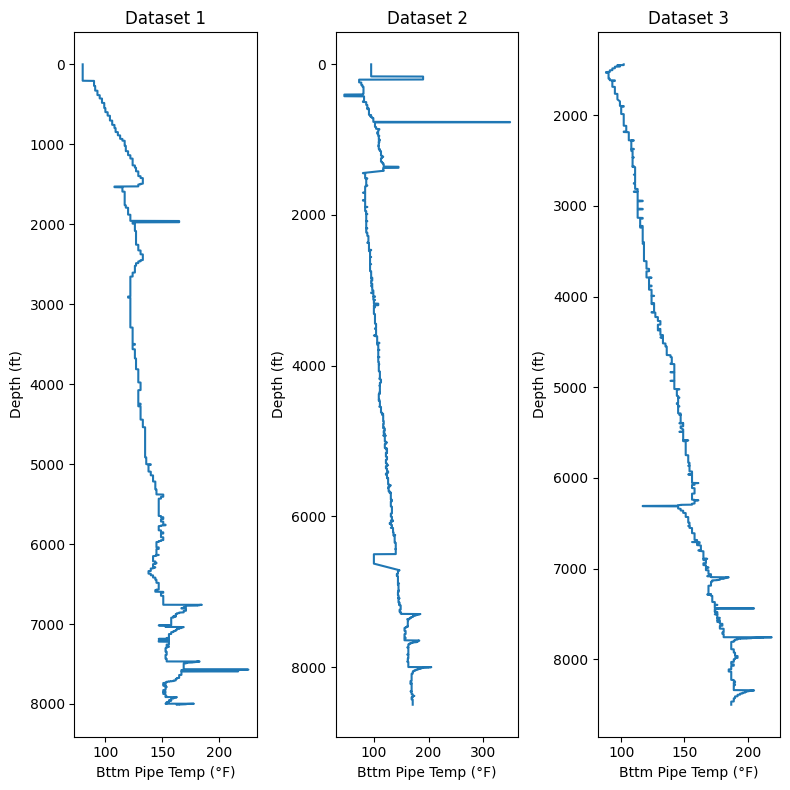

In [138]:
# create a vertical line chart for bttm column from df3_clean where y is depth and x is the bttm value
plt.figure(figsize=(8, 8))
plt.subplot(1, 3, 1)
plt.plot(df1_clean['Bttm Pipe Temp (°F)'], df1_clean['Depth(ft)'])
plt.gca().invert_yaxis()
plt.xlabel('Bttm Pipe Temp (°F)')
plt.ylabel('Depth (ft)')
plt.title('Dataset 1')

plt.subplot(1, 3, 2)
plt.plot(df2_clean['Bttm Pipe Temp (°F)'], df2_clean['Depth(ft)'])
plt.gca().invert_yaxis()
plt.xlabel('Bttm Pipe Temp (°F)')
plt.ylabel('Depth (ft)')
plt.title('Dataset 2')

plt.subplot(1, 3, 3)
plt.plot(df3_clean['Bttm Pipe Temp (°F)'], df3_clean['Depth(ft)'])
plt.gca().invert_yaxis()
plt.xlabel('Bttm Pipe Temp (°F)')
plt.ylabel('Depth (ft)')
plt.title('Dataset 3')

plt.tight_layout()
plt.show()


,Svy Azimuth (deg),Svy Inclination (deg),MSE Downhole (psi),MSE Total (psi),AD Delta-P SP (psi),Annular Velocity (ft/min),Mud Motor RPM (RPM),Pump SPM 1 (SPM),Flow In Rate (galUS/min),Pump SPM 2 (SPM),...,Top Drive Torque (kft·lbf),Total Rotations on DP (),Total Trip Volume (bbl),Trip Tank 1 (bbl),Trip Tank 2 (bbl),Trip Tank GL (bbl),WC Bit Weight (klb),WC Torque (ft·lbf),Washout Factor (),Water Pit (bbl)
Svy Azimuth (deg),1.000000,-0.062266,-0.350627,-0.412871,-0.209833,0.461573,0.461012,0.247940,0.461663,0.133242,...,-0.336927,-0.602052,0.522691,0.522285,0.525103,0.418788,0.633402,-0.327605,0.770176,-0.054138
Svy Inclination (deg),-0.062266,1.000000,0.119610,0.111316,-0.432616,-0.444969,-0.445412,-0.462323,-0.444464,0.099559,...,-0.401024,-0.167422,-0.146728,-0.146272,-0.152483,0.146093,-0.208575,-0.416804,-0.362576,0.054644
MSE Downhole (psi),-0.350627,0.119610,1.000000,0.974059,0.103147,-0.222998,-0.222870,-0.203440,-0.222935,-0.045048,...,0.114520,0.247237,-0.227836,-0.226802,-0.232852,-0.143436,-0.255865,0.109828,-0.364307,-0.006512
MSE Total (psi),-0.412871,0.111316,0.974059,1.000000,0.098007,-0.271146,-0.270953,-0.218135,-0.271141,-0.058604,...,0.163077,0.373627,-0.304297,-0.302738,-0.308465,-0.228420,-0.345040,0.158584,-0.419124,-0.011068
AD Delta-P SP (psi),-0.209833,-0.432616,0.103147,0.098007,1.000000,0.530288,0.530856,0.265298,0.530473,0.011163,...,0.805930,0.457560,0.342638,0.344229,0.341266,0.211274,0.234772,0.800632,0.127360,-0.015435
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Trip Tank GL (bbl),0.418788,0.146093,-0.143436,-0.228420,0.211274,0.572520,0.571975,0.070734,0.573241,0.166347,...,0.003185,-0.420963,0.919526,0.922493,0.911694,1.000000,0.730239,-0.002534,0.468444,0.006461
WC Bit Weight (klb),0.633402,-0.208575,-0.255865,-0.345040,0.234772,0.732897,0.732531,0.231918,0.733026,0.169679,...,0.029278,-0.490242,0.821198,0.822845,0.820073,0.730239,1.000000,0.031868,0.764957,-0.006714
WC Torque (ft·lbf),-0.327605,-0.416804,0.109828,0.158584,0.800632,0.380520,0.381076,0.212110,0.380539,-0.010766,...,0.994835,0.660172,0.128170,0.130981,0.129337,-0.002534,0.031868,1.000000,-0.081119,-0.056935
Washout Factor (),0.770176,-0.362576,-0.364307,-0.419124,0.127360,0.775460,0.775233,0.379594,0.775242,0.176527,...,-0.091209,-0.408434,0.661943,0.663006,0.664397,0.468444,0.764957,-0.081119,1.000000,-0.032954


In [151]:
import pandas as pd
from tabulate import tabulate

df1 = df1_clean[filtered_corr.index]
df2 = df2_clean[filtered_corr.index]
df3 = df3_clean[filtered_corr.index]
# Assuming df1, df2, and df3 are your DataFrames
summary_df1 = df1.describe()
summary_df2 = df2.describe()
summary_df3 = df3.describe()

# Convert summary statistics to Markdown tables
summary_md_df1 = tabulate(summary_df1, headers='keys', tablefmt='pipe')
summary_md_df2 = tabulate(summary_df2, headers='keys', tablefmt='pipe')
summary_md_df3 = tabulate(summary_df3, headers='keys', tablefmt='pipe')

# Print Markdown tables
print("Summary Statistics for df1:")
print(summary_md_df1)
print("\nSummary Statistics for df2:")
print(summary_md_df2)
print("\nSummary Statistics for df3:")
print(summary_md_df3)

Summary Statistics for df1:
|       |   Bttm Pipe Temp (°F) |   Pipe Length (ft) |   Depth(ft) |   Bit Position (ft) |   Hole Depth (ft) |   Svy Depth (ft) |   Gamma Depth (ft) |   Bit Time (hr) |   Time On Bottom (hr) |   Circulating Hrs (hr) |
|:------|----------------------:|-------------------:|------------:|--------------------:|------------------:|-----------------:|-------------------:|----------------:|----------------------:|-----------------------:|
| count |              7800     |            7800    |     7800    |             7800    |           7800    |          7800    |            7800    |       7800      |             7800      |              7800      |
| mean  |               133.12  |            2945.51 |     4070.37 |             4071.2  |           4071.2  |          3958.91 |            4010.65 |         23.0861 |               23.0861 |                37.4025 |
| std   |                18.364 |            2121.89 |     2278    |             2278.07 |          

In [6]:
df = pd.read_csv('../data/phase_1/training_dataset_3_inliers.csv')

In [9]:
X = df
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)

/home/atheer/miniconda3/envs/de/lib/python3.11/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
/home/atheer/miniconda3/envs/de/lib/python3.11/site-packages/statsmodels/regression/linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss


                  Feature          VIF
0       Svy Azimuth (deg)    79.584300
1   Svy Inclination (deg)    24.367814
2      MSE Downhole (psi)   140.851277
3         MSE Total (psi)   150.044353
4     AD Delta-P SP (psi)   126.231563
..                    ...          ...
79     Trip Tank GL (bbl)  2002.485080
80    WC Bit Weight (klb)  6366.480766
81     WC Torque (ft·lbf)   447.668116
82      Washout Factor ()  1458.787855
83        Water Pit (bbl)    35.148776

[84 rows x 2 columns]


In [8]:
import numpy as np
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.api import add_constant

# Creating a dataset with high multicollinearity
np.random.seed(42)
X1 = np.random.rand(100)
X2 = X1 * 0.95 + np.random.rand(100) * 0.05  # X2 is highly correlated with X1

# Put into a DataFrame
data = pd.DataFrame({'X1': X1, 'X2': X2})

# Add constant for the intercept
X = add_constant(data)

# Compute VIF
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)


  Feature         VIF
0   const    6.628110
1      X1  371.983231
2      X2  371.983231


In [10]:
# codebase/data/phase_1/training_dataset_3_inliers.csv
df1 = pd.read_csv('../data/phase_1/training_dataset_1_inliers.csv')
df2 = pd.read_csv('../data/phase_1/training_dataset_2_inliers.csv')
df3 = pd.read_csv('../data/phase_1/training_dataset_3_inliers.csv')

In [4]:
df_test = pd.read_csv('../data/phase_1/Test_dataset_1.csv')

In [31]:
df = pd.concat([df1, df2, df3], axis=0)

selected_cols =\
[
'Bttm Pipe Temp (°F)',
'Depth(ft)',
'Bit Time (hr)',
'Time On Bottom (hr)',
'Hook Load (klb)',
'Strks - Acc Fill (strokes)',
'ML Mud Temp IN (°F)',
'Bit Weight (klb)',
'Mud Temp In (°F)',
'Lst Jnt Time (s)',
'Mud Temp Out (°F)',
'Run Jnt Time (s)',
'Total Rotations on DP ()',
'MSE Total (psi)',
'Bit MSE (psi)',
'Gain Loss (bbl)',
'Rotary Torque (A)',
'Diff Press (psi)']

df = df[selected_cols]

In [32]:
# split test and train
from sklearn.model_selection import train_test_split
X = df.drop(columns=['Bttm Pipe Temp (°F)'])
y = df['Bttm Pipe Temp (°F)']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# scale the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [13]:
import numpy as np

In [29]:
# train the model using ridge regression 
from sklearn.linear_model import RidgeCV
ridge = RidgeCV(alphas=np.logspace(-3, 3, 7), store_cv_values=True)
ridge.fit(X_train_scaled, y_train)
y_pred = ridge.predict(X_test_scaled)
print("Ridge Regression")
print("MSE: ", mean_squared_error(y_test, y_pred))
print("R2: ", r2_score(y_test, y_pred))

# train the model using lasso regression
from sklearn.linear_model import LassoCV
lasso = LassoCV(alphas=np.logspace(-3, 3, 7), cv=5)
lasso.fit(X_train_scaled, y_train)
y_pred = lasso.predict(X_test_scaled)
print("Lasso Regression")
print("MSE: ", mean_squared_error(y_test, y_pred))
print("R2: ", r2_score(y_test, y_pred))

# train the model using elastic net regression
from sklearn.linear_model import ElasticNetCV
elastic_net = ElasticNetCV(alphas=np.logspace(-3, 3, 7), l1_ratio=0.5, cv=5)
elastic_net.fit(X_train_scaled, y_train)
y_pred = elastic_net.predict(X_test_scaled)
print("Elastic Net Regression")
print("MSE: ", mean_squared_error(y_test, y_pred))
print("R2: ", r2_score(y_test, y_pred))

# train the model using decision tree regression
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
param_grid = {
    'max_depth': [3, 5, 7, 9],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
dt = DecisionTreeRegressor()
grid_search = GridSearchCV(dt, param_grid, cv=5)
grid_search.fit(X_train_scaled, y_train)
y_pred = grid_search.predict(X_test_scaled)
print("Decision Tree Regression")
print("MSE: ", mean_squared_error(y_test, y_pred))
print("R2: ", r2_score(y_test, y_pred))




/home/atheer/miniconda3/envs/de/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:2385: FutureWarning: 'store_cv_values' is deprecated in version 1.5 and will be removed in 1.7. Use 'store_cv_results' instead.
  warnings.warn(


ValueError: Found input variables with inconsistent numbers of samples: [18264, 80]

In [36]:
# train the model using random forest regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
param_dist = {
    'n_estimators': randint(50, 200),
    'max_depth': randint(3, 10),
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 5)
}
rf = RandomForestRegressor()
random_search = RandomizedSearchCV(rf, param_distributions=param_dist, n_iter=100, cv=5)
random_search.fit(X_train_scaled, y_train)
y_pred = random_search.predict(X_test_scaled)
print("Random Forest Regression")
print("MSE: ", mean_squared_error(y_test, y_pred))
print("R2: ", r2_score(y_test, y_pred))





Random Forest Regression
MSE:  8.786720314111196
R2:  0.9877381061298763
